# Unsupervised Learning for Pattern Discovery and Customer Segmentation

## Task 1: Understand the Business Problem

### 1. What is the main business problem?
The main business problem for **PayFlow Business Solutions** is the financial instability caused by late invoice payments. Small and medium-sized businesses (SMEs) rely on timely payments to manage their cash flow, pay suppliers, and handle payroll. Late payments increase administrative burdens and create financial friction that hinders growth.

### 2. Why is customer/user segmentation useful for this business?
Customer segmentation is useful because it allows PayFlow to group customers based on shared characteristics and payment behaviors. Instead of a "one-size-fits-all" approach, segmentation helps identify high-risk groups that frequently pay late versus reliable groups that pay on time. This enables the business to allocate resources more efficiently, such as focusing collection efforts on the most problematic segments.

### 3. What kind of marketing decisions could be improved by discovering customer/user groups?
By discovering customer groups, PayFlow can improve several marketing and operational decisions:
- **Targeted Communication:** Sending proactive payment reminders to segments known for delay while maintaining a lighter touch with reliable customers.
- **Incentive Programs:** Offering early payment discounts to specific segments to improve cash flow.
- **Service Optimization:** Promoting the use of the online payment portal to segments that show lower digital engagement.
- **Resource Allocation:** Assigning dedicated account managers to enterprise-level or high-value segments that show complex payment patterns.

## Task 2: Prepare the Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Load the dataset
df = pd.read_excel('payflow_invoice_late_payment_dataset.xlsx')

# Inspect the dataset
print("Shape of the dataset:", df.shape)
print("\nColumn Names:\n", df.columns)
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum().sum())
print("\nDuplicate Rows:", df.duplicated().sum())
df.head()

Shape of the dataset: (360, 17)

Column Names:
 Index(['Invoice_ID', 'Customer_Segment', 'Industry', 'Region', 'Invoice_Month',
       'Invoice_Amount', 'Payment_Terms_Days', 'Customer_Tenure_Months',
       'Prior_Late_Payments', 'Avg_Days_To_Pay', 'Days_Since_Last_Order',
       'Dispute_Flag', 'Reminder_Count', 'Online_Portal_Use',
       'Early_Payment_Discount_Offered', 'Credit_Score_Band', 'Late_Payment'],
      dtype='object')

Data Types:
 Invoice_ID                         object
Customer_Segment                   object
Industry                           object
Region                             object
Invoice_Month                      object
Invoice_Amount                    float64
Payment_Terms_Days                  int64
Customer_Tenure_Months              int64
Prior_Late_Payments                 int64
Avg_Days_To_Pay                     int64
Days_Since_Last_Order               int64
Dispute_Flag                       object
Reminder_Count                      int64
On

,Invoice_ID,Customer_Segment,Industry,Region,Invoice_Month,Invoice_Amount,Payment_Terms_Days,Customer_Tenure_Months,Prior_Late_Payments,Avg_Days_To_Pay,Days_Since_Last_Order,Dispute_Flag,Reminder_Count,Online_Portal_Use,Early_Payment_Discount_Offered,Credit_Score_Band,Late_Payment
0,INV-20260001,Small Business,Construction,Prairies,Aug,5851.94,30,28,1,42,156,No,3,Yes,No,Medium,Yes
1,INV-20260002,Small Business,Healthcare Services,British Columbia,Aug,3224.65,30,34,2,47,153,Yes,2,Yes,No,High,No
2,INV-20260003,Mid-Market,Retail,Prairies,Dec,17946.67,30,12,2,38,19,No,2,No,No,High,Yes
3,INV-20260004,Small Business,Retail,British Columbia,Sep,5131.03,15,25,5,49,107,No,4,Yes,No,Low,Yes
4,INV-20260005,Mid-Market,Technology,Alberta,Aug,17553.63,60,14,0,61,46,No,2,Yes,No,Medium,Yes


### Feature Selection and Scaling
We will select the numerical features that are relevant for clustering customer behavior. 

**Important Note:** The `Late_Payment` column represents whether the current invoice was paid late. Since this is an unsupervised learning task aimed at discovering general behavior patterns rather than predicting a specific outcome, we DO NOT use `Late_Payment` for training the K-means model. It is kept in the dataset only for potential future validation or comparison against discovered segments.

In [2]:
# Select numerical features (excluding Late_Payment target)
numerical_features = [
    'Invoice_Amount', 
    'Payment_Terms_Days', 
    'Customer_Tenure_Months', 
    'Prior_Late_Payments', 
    'Avg_Days_To_Pay', 
    'Days_Since_Last_Order', 
    'Reminder_Count'
]

X = df[numerical_features]

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features scaled successfully.")
X_scaled_df = pd.DataFrame(X_scaled, columns=numerical_features)
X_scaled_df.head()

Features scaled successfully.


,Invoice_Amount,Payment_Terms_Days,Customer_Tenure_Months,Prior_Late_Payments,Avg_Days_To_Pay,Days_Since_Last_Order,Reminder_Count
0,-0.634211,-0.387870,-0.519481,0.019649,-0.064539,1.190645,1.288077
1,-0.750114,-0.387870,-0.293756,0.805610,0.258157,1.133095,0.503462
2,-0.100650,-0.387870,-1.121415,0.805610,-0.322696,-1.437471,0.503462
3,-0.666014,-1.541865,-0.632344,3.163492,0.387236,0.250662,2.072692
4,-0.117989,1.920118,-1.046173,-0.766312,1.161707,-0.919521,0.503462


## Task 3: Apply K-means Clustering

We will use the **Elbow Method** to determine the optimal number of clusters by plotting the Within-Cluster Sum of Squares (WCSS).

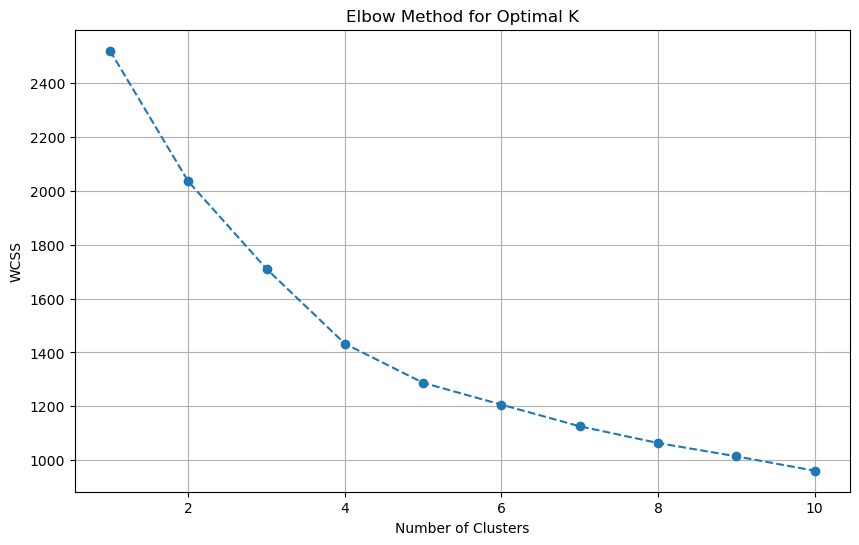

In [3]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Method
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

### Cluster Selection
Based on the Elbow Method, the slope significantly decreases after **k=4**. We will select 4 clusters as it provides a good balance between granularity and simplicity.

### Final Model Training

In [4]:
# Train final model with k=4
kmeans = KMeans(n_clusters=4, init='k-means++', max_iter=300, n_init=10, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

print("Final K-means model trained and labels added to the dataset.")
df.head()

Final K-means model trained and labels added to the dataset.


,Invoice_ID,Customer_Segment,Industry,Region,Invoice_Month,Invoice_Amount,Payment_Terms_Days,Customer_Tenure_Months,Prior_Late_Payments,Avg_Days_To_Pay,Days_Since_Last_Order,Dispute_Flag,Reminder_Count,Online_Portal_Use,Early_Payment_Discount_Offered,Credit_Score_Band,Late_Payment,Cluster
0,INV-20260001,Small Business,Construction,Prairies,Aug,5851.94,30,28,1,42,156,No,3,Yes,No,Medium,Yes,0
1,INV-20260002,Small Business,Healthcare Services,British Columbia,Aug,3224.65,30,34,2,47,153,Yes,2,Yes,No,High,No,0
2,INV-20260003,Mid-Market,Retail,Prairies,Dec,17946.67,30,12,2,38,19,No,2,No,No,High,Yes,1
3,INV-20260004,Small Business,Retail,British Columbia,Sep,5131.03,15,25,5,49,107,No,4,Yes,No,Low,Yes,0
4,INV-20260005,Mid-Market,Technology,Alberta,Aug,17553.63,60,14,0,61,46,No,2,Yes,No,Medium,Yes,3


## Task 4: Analyze and Interpret the Clusters

In [5]:
# Analyze cluster averages
cluster_analysis = df.groupby('Cluster')[numerical_features].mean()
cluster_analysis['Count'] = df.groupby('Cluster')['Invoice_ID'].count()
cluster_analysis

,Invoice_Amount,Payment_Terms_Days,Customer_Tenure_Months,Prior_Late_Payments,Avg_Days_To_Pay,Days_Since_Last_Order,Reminder_Count,Count
Cluster,,,,,,,,
0,8646.753529,34.705882,33.588235,3.294118,49.274510,106.784314,3.313725,51
1,13040.783949,25.796178,35.184713,0.560510,31.343949,92.853503,1.025478,157
2,65454.925490,34.411765,76.607843,0.666667,43.627451,88.960784,1.372549,51
3,14411.516040,49.900990,38.683168,0.603960,57.633663,91.633663,0.881188,101


### Analysis of Segments:
1. **How many segments did you find?**
   We identified **4 distinct customer segments**.

2. **What are the main characteristics of each segment? (Based on Cluster Averages)**
   - **Cluster 0 (High Risk):** Characterized by the highest financial risk, with an average of **3.29 prior late payments** and **3.31 reminders** sent (the highest across all groups). They also have the longest average days to pay (**49.2 days**) despite having relatively small invoice amounts (~$8,646).
   - **Cluster 1 (Reliable Small/Mid):** The fastest payers with an average of only **31.3 days to pay**. They have the lowest prior late payment history (**0.56**) and receive minimal reminders (**1.02**). These are consistent, low-maintenance customers.
   - **Cluster 2 (Enterprise Loyalists):** This group represents high-value accounts with the highest average invoice amount (**~$65,454**) and the longest relationship tenure (**76.6 months**). They are reliable partners with low late payment records (**0.66**).
   - **Cluster 3 (Extended Terms):** These customers have the longest agreed payment terms (**49.9 days**) and a corresponding average days to pay of **57.6 days**. Interestingly, they require the fewest reminders (**0.88**), showing that their longer payment cycle is well-managed and expected.

3. **How are the segments different from each other?**
   The segments are differentiated by **payment behavior vs. terms**: Cluster 0 struggles to meet terms, while Cluster 3 takes a long time but stays within agreed windows. They are also differentiated by **business scale**: Cluster 2 handles very large invoices compared to the others.

4. **Which segment may be the most valuable?**
   **Cluster 2 (Enterprise Loyalists)** is the most valuable. Their high invoice volume contributes most to revenue, and their long tenure suggests a stable, low-churn relationship.

5. **Which segment may need more marketing attention?**
   **Cluster 0 (High Risk)** requires operational attention and "re-education" marketing to improve their payment discipline and reduce the administrative burden of reminders.

## Task 5: Visualize the Clusters

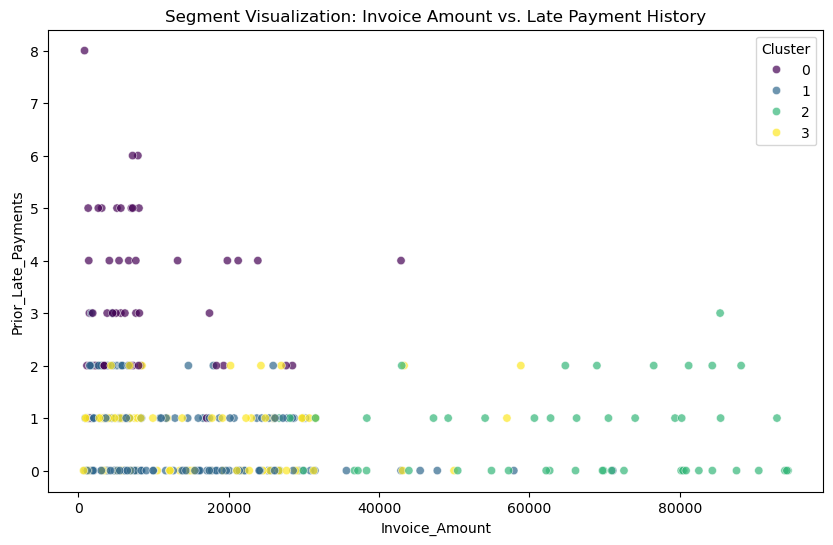

Interpretation: This plot clearly separates Cluster 2 (high value) on the far right due to its $65k+ average invoice amount. It also highlights Cluster 0 (top left), which shows consistently high late payment history (above 3.29 on average) despite having the smallest invoice sizes, marking them as the primary risk group.


In [6]:
# Visualization 1: Scatter Plot of Invoice Amount vs. Prior Late Payments
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Invoice_Amount', y='Prior_Late_Payments', hue='Cluster', palette='viridis', alpha=0.7)
plt.title('Segment Visualization: Invoice Amount vs. Late Payment History')
plt.show()

print("Interpretation: This plot clearly separates Cluster 2 (high value) on the far right due to its $65k+ average invoice amount. It also highlights Cluster 0 (top left), which shows consistently high late payment history (above 3.29 on average) despite having the smallest invoice sizes, marking them as the primary risk group.")

C:\Users\sukhi bajwa\AppData\Local\Temp\ipykernel_16772\2109541687.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_analysis.index, y=cluster_analysis['Reminder_Count'], palette='magma')


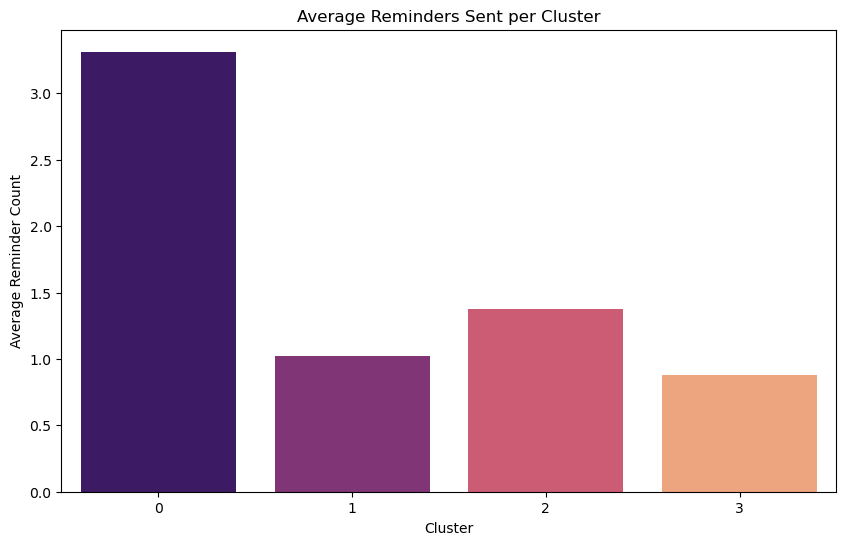

Interpretation: This chart quantifies the administrative burden for each group. Cluster 0 stands out with an average of over 3.3 reminders per invoice—more than 3x the amount required by Cluster 3 (0.88 reminders). This verifies that Cluster 0 is inefficient to manage and needs better automated interventions.


In [7]:
# Visualization 2: Bar Chart comparing Cluster Averages for Reminders
plt.figure(figsize=(10, 6))
sns.barplot(x=cluster_analysis.index, y=cluster_analysis['Reminder_Count'], palette='magma')
plt.title('Average Reminders Sent per Cluster')
plt.ylabel('Average Reminder Count')
plt.show()

print("Interpretation: This chart quantifies the administrative burden for each group. Cluster 0 stands out with an average of over 3.3 reminders per invoice—more than 3x the amount required by Cluster 3 (0.88 reminders). This verifies that Cluster 0 is inefficient to manage and needs better automated interventions.")

## Task 6: Business Interpretation

### 1. What patterns did you discover?
The analysis revealed that payment behavior is not solely tied to invoice size. Instead, we found a specific "High Risk" group (Cluster 0) that consistently requires reminders (3.3 avg) regardless of their small invoice amounts. We also identified an "Enterprise" group (Cluster 2) that provides the bulk of revenue and remains highly loyal (76+ months tenure).

### 2. How can the business use these customer segments?
PayFlow can use these segments to **automate and tailor workflows**. For example, reliable customers can be moved to automated tracks, while high-risk segments are flagged for human-led credit reviews before new orders are accepted.

### 3. What specific strategies would you suggest?
- **Cluster 0 (High Risk):** Implement **early intervention**. Send automated reminders 5 days *before* the due date. For repeat offenders, require a portion of the invoice to be paid upfront or restrict credit terms to 7 days.
- **Cluster 1 (Reliable Small/Mid):** Use **automated nudges**. These customers pay well; maintain their satisfaction with automated, friendly reminders and perhaps offer "loyalty points" for on-time payments to keep them in this segment.
- **Cluster 2 (Enterprise Loyalists):** Implement **relationship-based support**. Assign dedicated account managers and provide VIP support. Offer quarterly business reviews to ensure PayFlow remains their preferred partner.
- **Cluster 3 (Extended Terms):** Provide **payment planning tools**. Since they have long cycles, offer financial tools or dashboards within the portal that help them manage their own cash flow, ensuring they continue to meet their 50-day terms.

### 4. How can this help improve decision-making?
By identifying that Cluster 0 requires 3x the effort of others, management can justify investing in automated collection software. It also helps in credit risk assessment—new customers who match the profile of Cluster 0 can be handled with stricter terms from day one.

## Task 7: Limitations and Responsible AI Reflection

### 1. What is one limitation of your dataset or clustering model?
The dataset is synthetic and does not include external factors like seasonal economic shifts or industry-specific downturns which could significantly impact payment behavior.

### 2. Why does K-means not always produce perfect customer segments?
K-means assumes that clusters are spherical and of similar size, which isn't always true in business data. It is also highly sensitive to outliers, which can pull the cluster centers away from the actual dense regions.

### 3. What kind of bias or unfair decision could happen if used without review?
**Unfair Labeling:** Clustering may unfairly label a customer as "High Risk" based strictly on historical data without considering context. For example, a customer's industry or region might be facing a broader economic recession. If the model is used to automatically deny credit based on these labels, it could penalize businesses for factors outside their control, rather than poor behavior.

### 4. Why should human judgment still be used?
Human judgment provides context that data lacks. An account manager might know that a customer in Cluster 0 is currently undergoing a merger or has been a loyal partner for years and just needs a temporary extension. Empathy and relationship management cannot be replaced by clustering algorithms. Decisions that impact a customer's business (like cutting off credit) should always involve a human review.